In [1]:
import math
import time
import numpy as np
import pandas as pd
import datetime as dt
from pylab import plt, mpl

In [4]:
np.random.seed(1000)
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'

In [5]:
p = 0.55
f = p - (1-p)
f

0.10000000000000009

In [ ]:
I = 50
n = 100

In [11]:
def run_simulation(f):
    c = np.zeros((n,I))
    c[0] = 100
    for i in range(I):
        for t in range(1,n):
            o = np.random.binomial(1,p)
            if o> 0:
                c[t,i] = (1+f) * c[t-1, i]
            else:
                c[t,i] = (1-f) * c[t-1, i]
    return c

In [47]:
c_1 = run_simulation(f)

In [48]:
c_1.round(2)

array([[100.  , 100.  , 100.  , ..., 100.  , 100.  , 100.  ],
       [110.  ,  90.  , 110.  , ...,  90.  ,  90.  ,  90.  ],
       [ 99.  ,  99.  ,  99.  , ...,  99.  ,  81.  ,  81.  ],
       ...,
       [ 82.99, 123.97, 151.52, ..., 151.52, 226.35, 338.13],
       [ 91.29, 136.37, 136.37, ..., 136.37, 203.72, 371.94],
       [100.42, 150.01, 122.73, ..., 150.01, 183.34, 334.75]],
      shape=(100, 50))

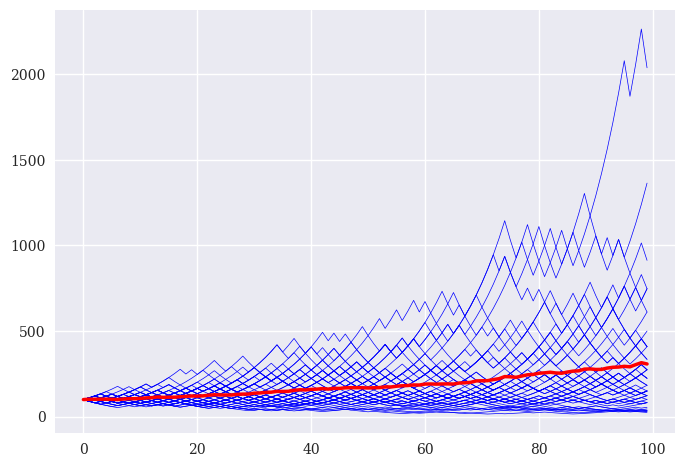

In [49]:
plt.Figure(figsize=(10,6))
plt.plot(c_1, 'b', lw=0.5)
plt.plot(c_1.mean(axis=1), 'r', lw=2.5);

In [50]:
c_2 = run_simulation(0.05)
c_3 = run_simulation(0.25)
c_4 = run_simulation(0.5)

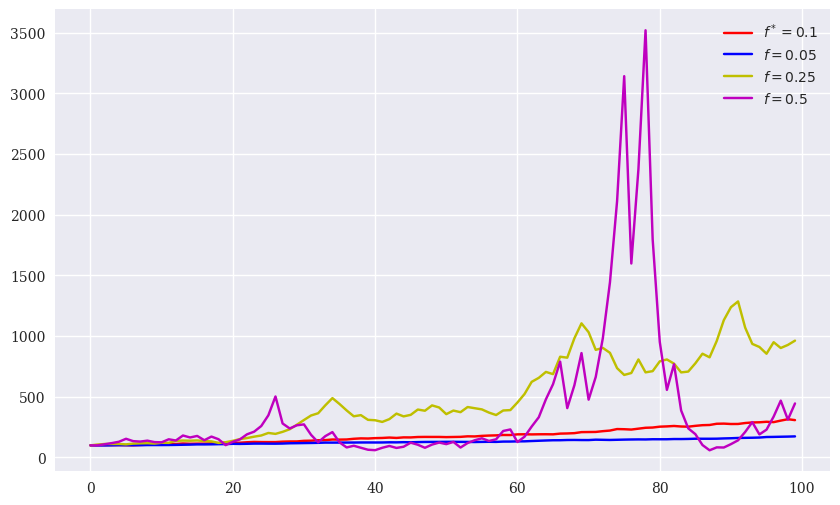

In [51]:
plt.figure(figsize=(10,6))
plt.plot(c_1.mean(axis=1), 'r', label='$f^*=0.1$')
plt.plot(c_2.mean(axis=1), 'b', label='$f=0.05$')
plt.plot(c_3.mean(axis=1), 'y', label='$f=0.25$')
plt.plot(c_4.mean(axis=1), 'm', label='$f=0.5$')
plt.legend(loc=0)

In [92]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                  index_col=0, parse_dates=True)
symbol = '.SPX'
data = pd.DataFrame(raw[symbol])
data['return']  = np.log(data / data.shift(1))
data.dropna(inplace=True)
data.tail()

,.SPX,return
Date,,
2019-12-23,3224.01,0.000866
2019-12-24,3223.38,-0.000195
2019-12-27,3240.02,0.000034
2019-12-30,3221.29,-0.005798
2019-12-31,3230.78,0.002942


In [93]:
mu = data['return'].mean() * 252
mu

np.float64(0.09992181916534204)

In [94]:
sigma = data['return'].std() * 252 ** 0.5
sigma

np.float64(0.14761569775486563)

In [95]:
r = 0.0
f = (mu - r) / sigma **2
f

np.float64(4.585590244019818)

In [96]:
equs = []
def kelly_starategy(f):
    global equs
    equ = 'equity_{:.2f}'.format(f)
    equs.append(equ)
    cap = 'capital_{:.2f}'.format(f)
    data[equ] = 1.0
    data[cap] = data[equ] * f
    for i, t in enumerate(data.index[1:]):
        t_1 = data.index[i]
        data.loc[t, cap] = data[cap].loc[t_1] * \
                            math.exp(data['return'].loc[t])
        data.loc[t, equ] = data[cap].loc[t] - \
                            data[cap].loc[t_1] + \
                            data[equ].loc[t_1]
        data.loc[t,cap] = data[equ].loc[t] * f
  

In [97]:
kelly_starategy(f * 0.5)
kelly_starategy(f * 0.66)
kelly_starategy(f)
print(data[equs].tail())


            equity_2.29  equity_3.03  equity_4.59
Date                                             
2019-12-23     6.628865     9.585294    14.205748
2019-12-24     6.625895     9.579626    14.193019
2019-12-27     6.626410     9.580610    14.195229
2019-12-30     6.538582     9.412991    13.818934
2019-12-31     6.582748     9.496919    14.005618


In [98]:
data

,.SPX,return,equity_2.29,capital_2.29,equity_3.03,capital_3.03,equity_4.59,capital_4.59
Date,,,,,,,,
2010-01-05,1136.52,0.003111,1.000000,2.292795,1.000000,3.026490,1.000000,4.585590
2010-01-06,1137.14,0.000545,1.001251,2.295663,1.001651,3.031486,1.002502,4.597061
2010-01-07,1141.69,0.003993,1.010436,2.316724,1.013781,3.068197,1.020896,4.681409
2010-01-08,1144.98,0.002878,1.017112,2.332030,1.022622,3.094956,1.034386,4.743270
2010-01-11,1146.98,0.001745,1.021186,2.341370,1.028029,3.111318,1.042671,4.781264
...,...,...,...,...,...,...,...,...
2019-12-23,3224.01,0.000866,6.628865,15.198628,9.585294,29.009793,14.205748,65.141741
2019-12-24,3223.38,-0.000195,6.625895,15.191819,9.579626,28.992637,14.193019,65.083369
2019-12-27,3240.02,0.000034,6.626410,15.193002,9.580610,28.995616,14.195229,65.093502


<Axes: xlabel='Date'>

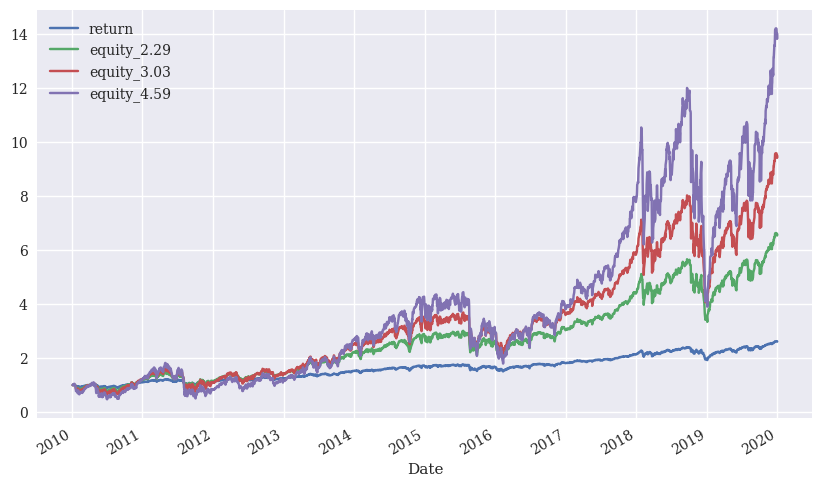

In [100]:
ax = data['return'].cumsum().apply(np.exp).plot(figsize=(10,6), legend=True)
data[equs].plot(ax=ax, legend=True)

In [85]:
data

,.SPX,return,equity_2.29,capital-2.29,capital_2.29,equity_3.03,capital_3.03,equity_4.59,capital_4.59
Date,,,,,,,,,
2010-01-05,1136.52,0.003111,1.000000,2.292795,2.292795,1.000000,3.026490,1.000000,4.585590
2010-01-06,1137.14,0.000545,1.001251,2.294046,2.295663,1.001651,3.031486,1.002502,4.597061
2010-01-07,1141.69,0.003993,1.010436,2.292795,2.316724,1.013781,3.068197,1.020896,4.681409
2010-01-08,1144.98,0.002878,1.017112,2.292795,2.332030,1.022622,3.094956,1.034386,4.743270
2010-01-11,1146.98,0.001745,1.021186,2.292795,2.341370,1.028029,3.111318,1.042671,4.781264
...,...,...,...,...,...,...,...,...,...
2019-12-23,3224.01,0.000866,6.628865,2.292795,15.198628,9.585294,29.009793,14.205748,65.141741
2019-12-24,3223.38,-0.000195,6.625895,2.292795,15.191819,9.579626,28.992637,14.193019,65.083369
2019-12-27,3240.02,0.000034,6.626410,2.292795,15.193002,9.580610,28.995616,14.195229,65.093502
